¡Hola, Oswaldo!

Mi nombre es Tonatiuh Cruz. Me complace revisar tu proyecto hoy.

Al identificar cualquier error inicialmente, simplemente los destacaré. Te animo a localizar y abordar los problemas de forma independiente como parte de tu preparación para un rol como data-analyst. En un entorno profesional, tu líder de equipo seguiría un enfoque similar. Si encuentras la tarea desafiante, proporcionaré una pista más específica en la próxima iteración.

Encontrarás mis comentarios a continuación - **por favor no los muevas, modifiques o elimines**.

Puedes encontrar mis comentarios en cajas verdes, amarillas o rojas como esta:

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Éxito. Todo está hecho correctamente.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Observaciones. Algunas recomendaciones.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Necesita corrección. El bloque requiere algunas correcciones. El trabajo no puede ser aceptado con comentarios en rojo.
</div>

Puedes responderme utilizando esto:

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante.</b> <a class="tocSkip"></a>


In [1]:
# 1. Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [2]:
# 2. Cargar datos
marketing_events = pd.read_csv('/datasets/ab_project_marketing_events_us.csv')
new_users = pd.read_csv('/datasets/final_ab_new_users_upd_us.csv')
events = pd.read_csv('/datasets/final_ab_events_upd_us.csv')
participants = pd.read_csv('/datasets/final_ab_participants_upd_us.csv')

In [3]:
# 3. Información general de los datasets
datasets = {
    'marketing_events': marketing_events,
    'new_users': new_users,
    'events': events,
    'participants': participants
}
for name, df in datasets.items():
    print(f'\n{"="*60}')
    print(name)
    print(f'{"="*60}')
    print('Filas y columnas:', df.shape)
    display(df.head())
    df.info()


marketing_events
Filas y columnas: (14, 4)


,name,regions,start_dt,finish_dt
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03
1,St. Valentine's Day Giveaway,"EU, CIS, APAC, N.America",2020-02-14,2020-02-16
2,St. Patric's Day Promo,"EU, N.America",2020-03-17,2020-03-19
3,Easter Promo,"EU, CIS, APAC, N.America",2020-04-12,2020-04-19
4,4th of July Promo,N.America,2020-07-04,2020-07-11


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   name       14 non-null     object
 1   regions    14 non-null     object
 2   start_dt   14 non-null     object
 3   finish_dt  14 non-null     object
dtypes: object(4)
memory usage: 576.0+ bytes

new_users
Filas y columnas: (58703, 4)


,user_id,first_date,region,device
0,D72A72121175D8BE,2020-12-07,EU,PC
1,F1C668619DFE6E65,2020-12-07,N.America,Android
2,2E1BF1D4C37EA01F,2020-12-07,EU,PC
3,50734A22C0C63768,2020-12-07,EU,iPhone
4,E1BDDCE0DAFA2679,2020-12-07,N.America,iPhone


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58703 entries, 0 to 58702
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     58703 non-null  object
 1   first_date  58703 non-null  object
 2   region      58703 non-null  object
 3   device      58703 non-null  object
dtypes: object(4)
memory usage: 1.8+ MB

events
Filas y columnas: (423761, 4)


,user_id,event_dt,event_name,details
0,E1BDDCE0DAFA2679,2020-12-07 20:22:03,purchase,99.99
1,7B6452F081F49504,2020-12-07 09:22:53,purchase,9.99
2,9CD9F34546DF254C,2020-12-07 12:59:29,purchase,4.99
3,96F27A054B191457,2020-12-07 04:02:40,purchase,4.99
4,1FD7660FDF94CA1F,2020-12-07 10:15:09,purchase,4.99


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 423761 entries, 0 to 423760
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   user_id     423761 non-null  object 
 1   event_dt    423761 non-null  object 
 2   event_name  423761 non-null  object 
 3   details     60314 non-null   float64
dtypes: float64(1), object(3)
memory usage: 12.9+ MB

participants
Filas y columnas: (14525, 3)


,user_id,group,ab_test
0,D1ABA3E2887B6A73,A,recommender_system_test
1,A7A3664BD6242119,A,recommender_system_test
2,DABC14FDDFADD29E,A,recommender_system_test
3,04988C5DF189632E,A,recommender_system_test
4,4FF2998A348C484F,A,recommender_system_test


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
dtypes: object(3)
memory usage: 340.6+ KB


In [4]:
# Convertir fechas
marketing_events['start_dt'] = pd.to_datetime(marketing_events['start_dt'])
marketing_events['finish_dt'] = pd.to_datetime(marketing_events['finish_dt'])

new_users['first_date'] = pd.to_datetime(new_users['first_date'])

events['event_dt'] = pd.to_datetime(events['event_dt'])

In [5]:
# Comprobar los tipos 
print('marketing_events:')
print(marketing_events.dtypes)

print('\nnew_users:')
print(new_users.dtypes)

print('\nevents:')
print(events.dtypes)

print('\nparticipants:')
print(participants.dtypes)

marketing_events:
name                 object
regions              object
start_dt     datetime64[ns]
finish_dt    datetime64[ns]
dtype: object

new_users:
user_id               object
first_date    datetime64[ns]
region                object
device                object
dtype: object

events:
user_id               object
event_dt      datetime64[ns]
event_name            object
details              float64
dtype: object

participants:
user_id    object
group      object
ab_test    object
dtype: object


In [6]:
# 5. Valores ausentes
for name, df in datasets.items():
    print(f'\n{name}')
    print(df.isna().sum())


marketing_events
name         0
regions      0
start_dt     0
finish_dt    0
dtype: int64

new_users
user_id       0
first_date    0
region        0
device        0
dtype: int64

events
user_id            0
event_dt           0
event_name         0
details       363447
dtype: int64

participants
user_id    0
group      0
ab_test    0
dtype: int64


In [7]:
# Porcentajes
for name, df in datasets.items():
    missing = df.isna().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    
    result = pd.DataFrame({
        'missing': missing,
        'percentage': missing_pct
    })
    
    print(f'\n{name}')
    display(result[result['missing'] > 0])


marketing_events


,missing,percentage



new_users


,missing,percentage



events


,missing,percentage
details,363447,85.77



participants


,missing,percentage


In [8]:
# 6. Duplicados
for name, df in datasets.items():
    print(f'{name}: {df.duplicated().sum()} filas duplicadas')

marketing_events: 0 filas duplicadas
new_users: 0 filas duplicadas
events: 0 filas duplicadas
participants: 0 filas duplicadas


In [9]:
# Duplicados por usuario
print('Usuarios duplicados en new_users:',
      new_users['user_id'].duplicated().sum())

print('Usuarios duplicados en participants:',
      participants['user_id'].duplicated().sum())

Usuarios duplicados en new_users: 0
Usuarios duplicados en participants: 887


<div class="alert alert-block alert-success">
    <b>Comentario del revisor:</b> <a class="tocSkip"></a>
    
Gran trabajo con la carga inicial de los datos, esto lo complementas mediante las funciones  info. Además, realizas un análisis de registros duplicados que pudieran sesgar nuestros resultados. 


In [10]:
# 7. Seleccionar la prueba correcta
participants_test = participants[
    participants['ab_test'] == 'recommender_system_test'
].copy()

print('Participantes de recommender_system_test:',
      participants_test['user_id'].nunique())

display(participants_test.head())

Participantes de recommender_system_test: 3675


,user_id,group,ab_test
0,D1ABA3E2887B6A73,A,recommender_system_test
1,A7A3664BD6242119,A,recommender_system_test
2,DABC14FDDFADD29E,A,recommender_system_test
3,04988C5DF189632E,A,recommender_system_test
4,4FF2998A348C484F,A,recommender_system_test


In [11]:
# 8. Número de usuarios por grupo
group_sizes = (
    participants_test
    .groupby('group')['user_id']
    .nunique()
)

print(group_sizes)

group
A    2747
B     928
Name: user_id, dtype: int64


In [12]:
# Porcentaje 
group_sizes_pct = (
    group_sizes / group_sizes.sum() * 100
).round(2)

print(group_sizes_pct)

group
A    74.75
B    25.25
Name: user_id, dtype: float64


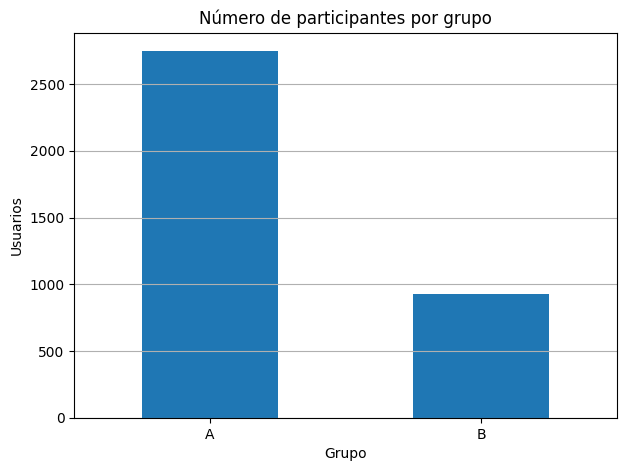

In [13]:
# Grafico
group_sizes.plot(
    kind='bar',
    figsize=(7, 5)
)

plt.title('Número de participantes por grupo')
plt.xlabel('Grupo')
plt.ylabel('Usuarios')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

In [14]:
# 9. Usuarios presentes en ambos grupos
groups_per_user = (
    participants_test
    .groupby('user_id')['group']
    .nunique()
)

users_both_groups = groups_per_user[
    groups_per_user > 1
]

print(
    'Usuarios presentes en ambos grupos:',
    len(users_both_groups)
)

Usuarios presentes en ambos grupos: 0


In [15]:
# 10. Usuarios que participan en más de una prueba
tests_per_user = (
    participants
    .groupby('user_id')['ab_test']
    .nunique()
)

multiple_tests = tests_per_user[
    tests_per_user > 1
]

print(
    'Usuarios que participan en más de una prueba:',
    len(multiple_tests)
)

Usuarios que participan en más de una prueba: 887


In [16]:
#11. Comprobar las pruebas disponibles
participants.groupby('ab_test')['user_id'].nunique()

ab_test
interface_eu_test          10850
recommender_system_test     3675
Name: user_id, dtype: int64

In [17]:
# 12. Unir participantes con datos de usuarios
participants_test = participants_test.merge(
    new_users,
    on='user_id',
    how='left'
)

print(participants_test.shape)
display(participants_test.head())

(3675, 6)


,user_id,group,ab_test,first_date,region,device
0,D1ABA3E2887B6A73,A,recommender_system_test,2020-12-07,EU,PC
1,A7A3664BD6242119,A,recommender_system_test,2020-12-20,EU,iPhone
2,DABC14FDDFADD29E,A,recommender_system_test,2020-12-08,EU,Mac
3,04988C5DF189632E,A,recommender_system_test,2020-12-14,EU,iPhone
4,4FF2998A348C484F,A,recommender_system_test,2020-12-20,EU,Mac


In [18]:
# 13. Revisar regiones
print(participants_test['region'].value_counts())

print('\nPorcentajes:')
print(
    (participants_test['region'].value_counts(normalize=True) * 100)
    .round(2)
)

EU           3481
N.America     119
APAC           45
CIS            30
Name: region, dtype: int64

Porcentajes:
EU           94.72
N.America     3.24
APAC          1.22
CIS           0.82
Name: region, dtype: float64


In [19]:
# usuarios fuera de la UE
outside_eu = participants_test[
    participants_test['region'] != 'EU'
]

print('Usuarios fuera de la UE:', outside_eu['user_id'].nunique())

Usuarios fuera de la UE: 194


In [20]:
# 14. Revisar fechas de registro
print('Primera fecha de registro:',
      participants_test['first_date'].min())

print('Última fecha de registro:',
      participants_test['first_date'].max())

Primera fecha de registro: 2020-12-07 00:00:00
Última fecha de registro: 2020-12-21 00:00:00


In [21]:
# registros fuera de periodo
invalid_dates = participants_test[
    (participants_test['first_date'] < '2020-12-07') |
    (participants_test['first_date'] > '2020-12-21')
]

print(
    'Usuarios registrados fuera del período:',
    invalid_dates['user_id'].nunique()
)

Usuarios registrados fuera del período: 0


In [22]:
# 15. Usuarios por fecha de registro
daily_users = (
    participants_test
    .groupby(['first_date', 'group'])['user_id']
    .nunique()
    .reset_index(name='users')
)

display(daily_users)

,first_date,group,users
0,2020-12-07,A,163
1,2020-12-07,B,182
2,2020-12-08,A,98
3,2020-12-08,B,44
4,2020-12-09,A,82
5,2020-12-09,B,85
6,2020-12-10,A,66
7,2020-12-10,B,33
8,2020-12-11,A,92
9,2020-12-11,B,21


<div class="alert alert-block alert-success">
    <b>Comentario del revisor:</b> <a class="tocSkip"></a>
    
Excelente trabajo,  antes de realizar el análisis realizas los siguientes filtros que nos mencionan en el proyecto:


    - La región es la indicada
    - Verificar que consideramos los primeros 14 días desde que se registraron los usuarios
    - Que la prueba es la correcta
    - Que las pruebas son excluyentes


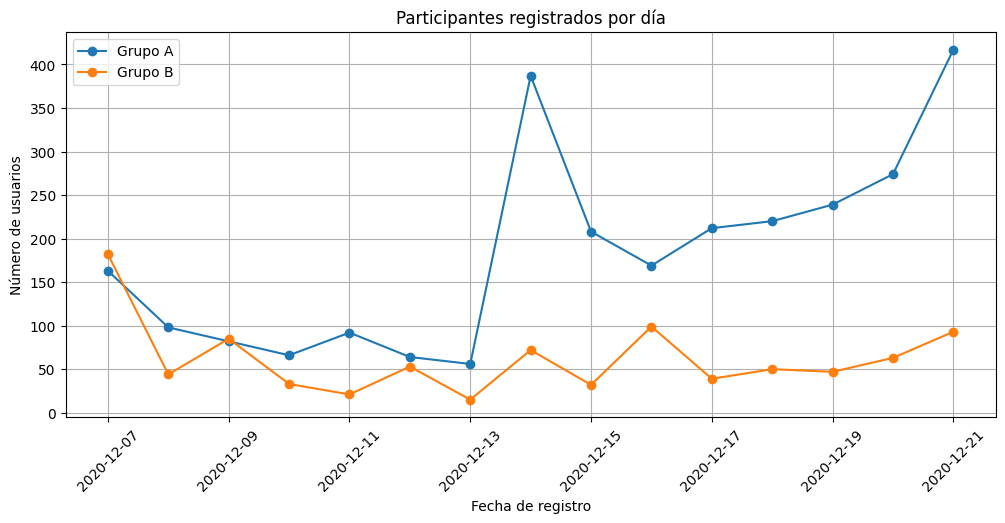

In [23]:
# Grafico
plt.figure(figsize=(12, 5))

for group in ['A', 'B']:
    data = daily_users[daily_users['group'] == group]
    
    plt.plot(
        data['first_date'],
        data['users'],
        marker='o',
        label=f'Grupo {group}'
    )

plt.title('Participantes registrados por día')
plt.xlabel('Fecha de registro')
plt.ylabel('Número de usuarios')
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.show()

In [24]:
# 16. Unir eventos con participantes
test_events = events.merge(
    participants_test[
        ['user_id', 'group', 'first_date', 'region']
    ],
    on='user_id',
    how='inner'
)

print(test_events.shape)
display(test_events.head())

(23909, 7)


,user_id,event_dt,event_name,details,group,first_date,region
0,831887FE7F2D6CBA,2020-12-07 06:50:29,purchase,4.99,A,2020-12-07,EU
1,831887FE7F2D6CBA,2020-12-09 02:19:17,purchase,99.99,A,2020-12-07,EU
2,831887FE7F2D6CBA,2020-12-07 06:50:30,product_cart,NaN,A,2020-12-07,EU
3,831887FE7F2D6CBA,2020-12-08 10:52:27,product_cart,NaN,A,2020-12-07,EU
4,831887FE7F2D6CBA,2020-12-09 02:19:17,product_cart,NaN,A,2020-12-07,EU


In [25]:
# 17. Revisar tipos de eventos
print(test_events['event_name'].value_counts())

login           10837
product_page     6702
purchase         3210
product_cart     3160
Name: event_name, dtype: int64


In [26]:
# 18. Fechas de los eventos
print('Primer evento:',
      test_events['event_dt'].min())

print('Último evento:',
      test_events['event_dt'].max())

Primer evento: 2020-12-07 00:05:57
Último evento: 2020-12-30 12:42:57


In [27]:
# 19. Calcular días desde el registro
test_events['days_since_registration'] = (
    test_events['event_dt'].dt.normalize()
    - test_events['first_date'].dt.normalize()
).dt.days

In [28]:
test_events[
    'days_since_registration'
].describe()

count    23909.000000
mean         3.154168
std          4.053194
min          0.000000
25%          0.000000
50%          2.000000
75%          5.000000
max         23.000000
Name: days_since_registration, dtype: float64

In [29]:
# 20. Mantener solamente los primeros 14 días
test_events_14d = test_events[
    (test_events['days_since_registration'] >= 0) &
    (test_events['days_since_registration'] < 14)
].copy()

print(
    'Eventos dentro de los primeros 14 días:',
    len(test_events_14d)
)

Eventos dentro de los primeros 14 días: 23151


In [30]:
# Comprobación
print(
    'Día mínimo:',
    test_events_14d['days_since_registration'].min()
)

print(
    'Día máximo:',
    test_events_14d['days_since_registration'].max()
)

Día mínimo: 0
Día máximo: 13


In [31]:
# 21. Eventos por usuario
events_per_user = (
    test_events_14d
    .groupby(['user_id', 'group'])
    .size()
    .reset_index(name='event_count')
)

display(events_per_user.head())

,user_id,group,event_count
0,001064FEAAB631A1,B,6
1,0010A1C096941592,A,12
2,00341D8401F0F665,A,2
3,003DF44D7589BBD4,A,15
4,00505E15A9D81546,A,5


In [32]:
# Estadisticas
events_per_user.groupby('group')['event_count'].describe()

,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
A,2747.0,6.614853,3.663491,1.0,4.0,6.0,9.0,24.0
B,928.0,5.366379,3.222666,1.0,3.0,4.0,6.0,24.0


In [33]:
# 22. Comparar eventos por usuario entre grupos
events_per_user.groupby('group')['event_count'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
)

,count,mean,median,std,min,max
group,,,,,,
A,2747,6.614853,6,3.663491,1,24
B,928,5.366379,4,3.222666,1,24


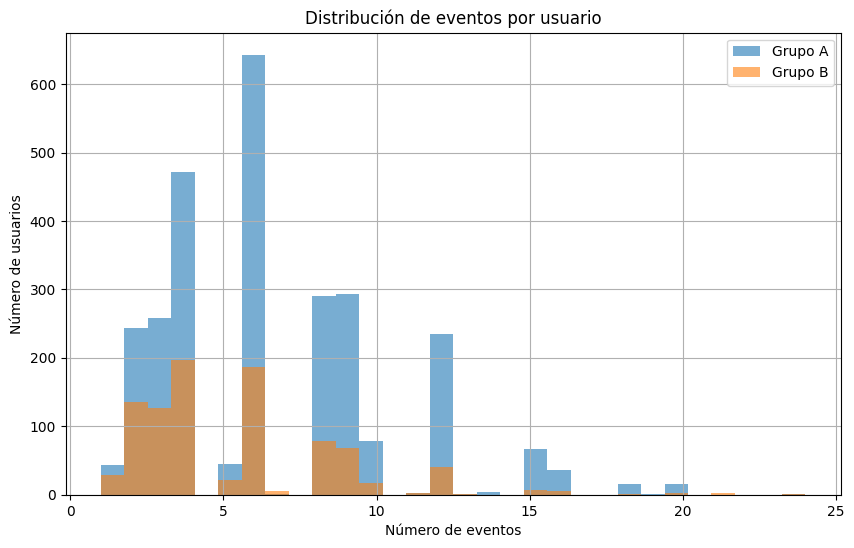

In [34]:
# Grafico
plt.figure(figsize=(10, 6))

for group in ['A', 'B']:
    data = events_per_user[
        events_per_user['group'] == group
    ]['event_count']
    
    plt.hist(
        data,
        bins=30,
        alpha=0.6,
        label=f'Grupo {group}'
    )

plt.title('Distribución de eventos por usuario')
plt.xlabel('Número de eventos')
plt.ylabel('Número de usuarios')
plt.legend()
plt.grid()
plt.show()

In [35]:
# 23. Eventos por día
daily_events = (
    test_events_14d
    .groupby(['days_since_registration', 'group'])
    .size()
    .reset_index(name='events')
)

display(daily_events)

,days_since_registration,group,events
0,0,A,6207
1,0,B,1924
2,1,A,2982
3,1,B,772
4,2,A,2079
5,2,B,499
6,3,A,1455
7,3,B,350
8,4,A,999
9,4,B,281


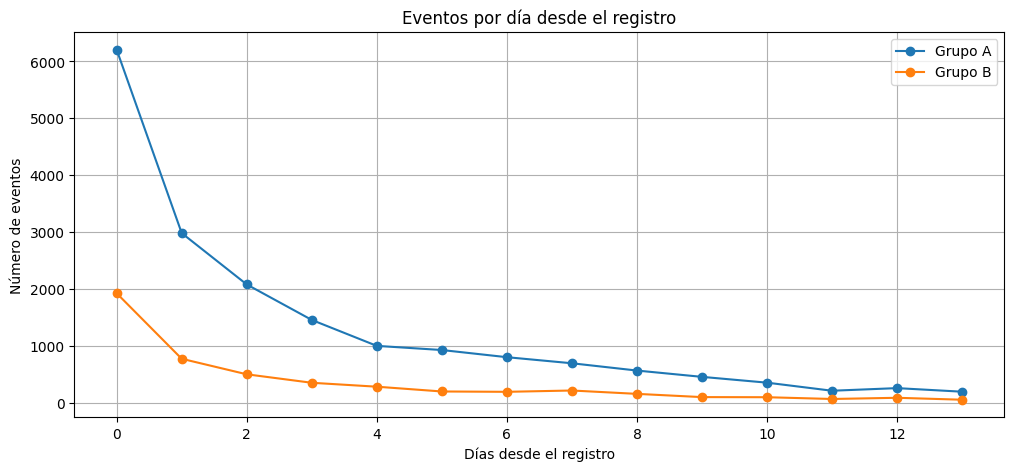

In [36]:
# Grafico
plt.figure(figsize=(12, 5))

for group in ['A', 'B']:
    data = daily_events[
        daily_events['group'] == group
    ]
    
    plt.plot(
        data['days_since_registration'],
        data['events'],
        marker='o',
        label=f'Grupo {group}'
    )

plt.title('Eventos por día desde el registro')
plt.xlabel('Días desde el registro')
plt.ylabel('Número de eventos')
plt.legend()
plt.grid()
plt.show()

In [37]:
# 24. Eventos diarios por tipo
daily_event_type = (
    test_events_14d
    .groupby(['days_since_registration', 'event_name'])
    .size()
    .unstack(fill_value=0)
)

display(daily_event_type)

event_name,login,product_cart,product_page,purchase
days_since_registration,,,,
0,3649,1073,2287,1122
1,1713,499,1046,496
2,1174,344,716,344
3,817,247,490,251
4,573,169,369,169
5,502,150,321,150
6,452,126,282,131
7,408,117,256,126
8,338,98,194,90


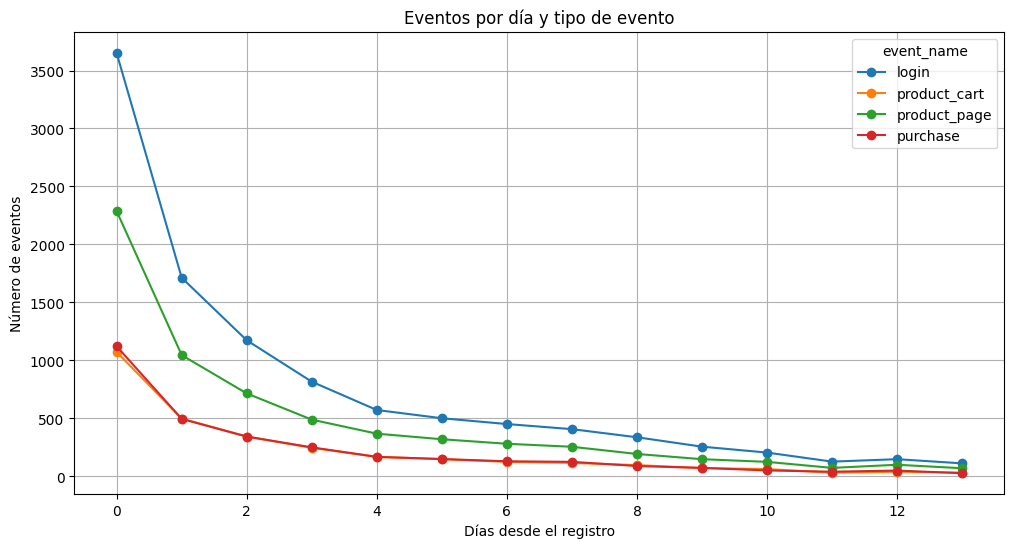

In [38]:
# Grafico
daily_event_type.plot(
    figsize=(12, 6),
    marker='o'
)

plt.title('Eventos por día y tipo de evento')
plt.xlabel('Días desde el registro')
plt.ylabel('Número de eventos')
plt.grid()
plt.show()

In [39]:
# 25. Analizar campañas de marketing
marketing_events.sort_values('start_dt')

,name,regions,start_dt,finish_dt
6,Chinese New Year Promo,APAC,2020-01-25,2020-02-07
1,St. Valentine's Day Giveaway,"EU, CIS, APAC, N.America",2020-02-14,2020-02-16
8,International Women's Day Promo,"EU, CIS, APAC",2020-03-08,2020-03-10
2,St. Patric's Day Promo,"EU, N.America",2020-03-17,2020-03-19
3,Easter Promo,"EU, CIS, APAC, N.America",2020-04-12,2020-04-19
7,Labor day (May 1st) Ads Campaign,"EU, CIS, APAC",2020-05-01,2020-05-03
9,Victory Day CIS (May 9th) Event,CIS,2020-05-09,2020-05-11
11,Dragon Boat Festival Giveaway,APAC,2020-06-25,2020-07-01
4,4th of July Promo,N.America,2020-07-04,2020-07-11
13,Chinese Moon Festival,APAC,2020-10-01,2020-10-07


In [40]:
# Campañas que coinciden con el periodo de la prueba
test_start = pd.Timestamp('2020-12-07')
test_end = pd.Timestamp('2021-01-01')

marketing_during_test = marketing_events[
    (marketing_events['start_dt'] <= test_end) &
    (marketing_events['finish_dt'] >= test_start)
].copy()

display(marketing_during_test)

,name,regions,start_dt,finish_dt
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03
10,CIS New Year Gift Lottery,CIS,2020-12-30,2021-01-07


In [41]:
# Campaña dirigida a las UE
marketing_eu = marketing_during_test[
    marketing_during_test['regions'].str.contains(
        'EU',
        case=False,
        na=False
    )
]

display(marketing_eu)

,name,regions,start_dt,finish_dt
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03


In [42]:
# 26. Crear el embudo
funnel = (
    test_events_14d[
        test_events_14d['event_name'].isin(
            ['product_page', 'product_cart', 'purchase']
        )
    ]
    .groupby(['group', 'event_name'])['user_id']
    .nunique()
    .unstack(fill_value=0)
)

In [43]:
# ordenar
funnel = funnel.reindex(
    columns=[
        'product_page',
        'product_cart',
        'purchase'
    ],
    fill_value=0
)

display(funnel)

event_name,product_page,product_cart,purchase
group,,,
A,1780,824,872
B,523,255,256


In [44]:
# 27. Número total de usuarios por grupo
group_users = (
    participants_test
    .groupby('group')['user_id']
    .nunique()
)

print(group_users)

group
A    2747
B     928
Name: user_id, dtype: int64


In [45]:
# 28. Conversión de cada etapa
conversion = (
    funnel
    .div(group_users, axis=0)
    * 100
)

conversion = conversion.round(2)
display(conversion)

event_name,product_page,product_cart,purchase
group,,,
A,64.80,30.00,31.74
B,56.36,27.48,27.59


In [46]:
# 29. Cambio relativo de B respecto a A
relative_change = (
    (conversion.loc['B'] / conversion.loc['A']) - 1
) * 100

relative_change = relative_change.round(2)

display(relative_change)

event_name
product_page   -13.02
product_cart    -8.40
purchase       -13.07
dtype: float64

In [47]:
# Si B consiguió el aumento esperado del 10%
comparison = pd.DataFrame({
    'conversion_A_%': conversion.loc['A'],
    'conversion_B_%': conversion.loc['B'],
    'change_B_vs_A_%': relative_change,
    'target_10%': relative_change >= 10
})

display(comparison)

,conversion_A_%,conversion_B_%,change_B_vs_A_%,target_10%
event_name,,,,
product_page,64.80,56.36,-13.02,False
product_cart,30.00,27.48,-8.40,False
purchase,31.74,27.59,-13.07,False


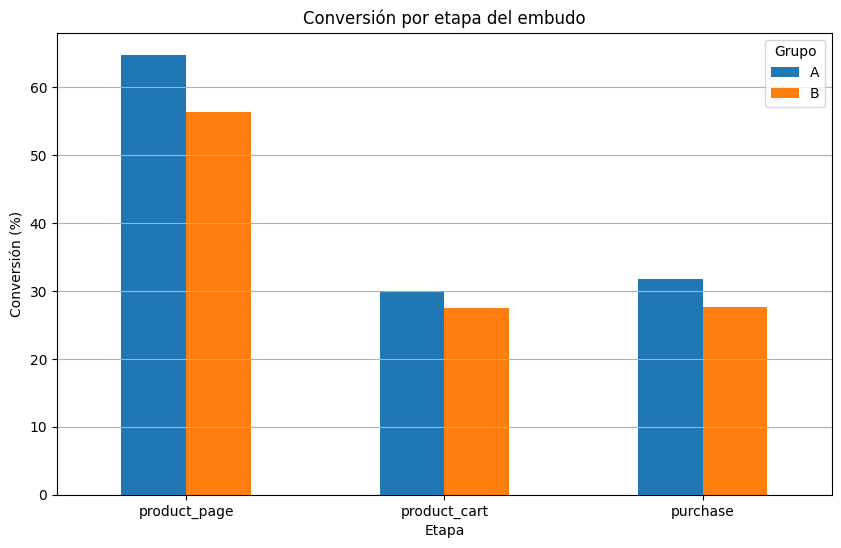

In [48]:
# 30. Gráfico de conversión
conversion.T.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Conversión por etapa del embudo')
plt.xlabel('Etapa')
plt.ylabel('Conversión (%)')
plt.xticks(rotation=0)
plt.legend(title='Grupo')
plt.grid(axis='y')
plt.show()

In [49]:
# 31. Conversión entre etapas consecutivas
stage_conversion = pd.DataFrame(index=funnel.index)

stage_conversion['product_page_to_cart'] = (
    funnel['product_cart'] /
    funnel['product_page'] * 100
)

stage_conversion['product_cart_to_purchase'] = (
    funnel['purchase'] /
    funnel['product_cart'] * 100
)

stage_conversion = stage_conversion.round(2)

display(stage_conversion)

,product_page_to_cart,product_cart_to_purchase
group,,
A,46.29,105.83
B,48.76,100.39


In [50]:
# 32. Prueba z
z_results = []

for event in [
    'product_page',
    'product_cart',
    'purchase'
]:
    
    successes = np.array([
        funnel.loc['A', event],
        funnel.loc['B', event]
    ])
    
    observations = np.array([
        group_users['A'],
        group_users['B']
    ])
    
    z_stat, p_value = proportions_ztest(
        successes,
        observations,
        alternative='two-sided'
    )
    
    z_results.append({
        'event': event,
        'users_A': observations[0],
        'users_B': observations[1],
        'successes_A': successes[0],
        'successes_B': successes[1],
        'conversion_A': successes[0] / observations[0],
        'conversion_B': successes[1] / observations[1],
        'z_stat': z_stat,
        'p_value': p_value
    })

z_results = pd.DataFrame(z_results)
display(z_results)

,event,users_A,users_B,successes_A,successes_B,conversion_A,conversion_B,z_stat,p_value
0,product_page,2747,928,1780,523,0.647980,0.563578,4.595797,0.000004
1,product_cart,2747,928,824,255,0.299964,0.274784,1.456161,0.145348
2,purchase,2747,928,872,256,0.317437,0.275862,2.374087,0.017592


In [51]:
# 33. Evaluar significancia estadística
alpha = 0.05

z_results['significant'] = (
    z_results['p_value'] < alpha
)

display(z_results)

,event,users_A,users_B,successes_A,successes_B,conversion_A,conversion_B,z_stat,p_value,significant
0,product_page,2747,928,1780,523,0.647980,0.563578,4.595797,0.000004,True
1,product_cart,2747,928,824,255,0.299964,0.274784,1.456161,0.145348,False
2,purchase,2747,928,872,256,0.317437,0.275862,2.374087,0.017592,True


In [52]:
# 34. Corrección por múltiples comparaciones
alpha_bonferroni = alpha / 3

print(
    'Nivel de significancia corregido:',
    alpha_bonferroni
)

Nivel de significancia corregido: 0.016666666666666666


In [53]:
z_results['significant_bonferroni'] = (
    z_results['p_value'] < alpha_bonferroni
)

display(z_results)

,event,users_A,users_B,successes_A,successes_B,conversion_A,conversion_B,z_stat,p_value,significant,significant_bonferroni
0,product_page,2747,928,1780,523,0.647980,0.563578,4.595797,0.000004,True,True
1,product_cart,2747,928,824,255,0.299964,0.274784,1.456161,0.145348,False,False
2,purchase,2747,928,872,256,0.317437,0.275862,2.374087,0.017592,True,False


In [54]:
# 35. Generar interpretación automática de la prueba z
for _, row in z_results.iterrows():
    
    event = row['event']
    p_value = row['p_value']
    
    if p_value < alpha_bonferroni:
        result = 'La diferencia es estadísticamente significativa.'
    else:
        result = 'No hay evidencia suficiente de una diferencia estadísticamente significativa.'
    
    print(
        f"{event}: p-value = {p_value:.4f}. {result}"
    )

product_page: p-value = 0.0000. La diferencia es estadísticamente significativa.
product_cart: p-value = 0.1453. No hay evidencia suficiente de una diferencia estadísticamente significativa.
purchase: p-value = 0.0176. No hay evidencia suficiente de una diferencia estadísticamente significativa.


In [55]:
# 36. Resumen final del experimento
summary = comparison.copy()

summary['p_value'] = (
    z_results
    .set_index('event')['p_value']
)

summary['statistically_significant'] = (
    z_results
    .set_index('event')['significant_bonferroni']
)

display(summary)

,conversion_A_%,conversion_B_%,change_B_vs_A_%,target_10%,p_value,statistically_significant
event_name,,,,,,
product_page,64.80,56.36,-13.02,False,0.000004,True
product_cart,30.00,27.48,-8.40,False,0.145348,False
purchase,31.74,27.59,-13.07,False,0.017592,False


In [56]:
# 37. Verificación de los objetivos
print('RESULTADOS DEL EXPERIMENTO')
print('=' * 60)

for event in ['product_page', 'product_cart', 'purchase']:
    
    change = relative_change[event]
    p_value = z_results.loc[
        z_results['event'] == event,
        'p_value'
    ].iloc[0]
    
    significant = p_value < alpha_bonferroni
    
    print(f'\n{event}')
    print(f'Cambio de B respecto a A: {change:.2f}%')
    print(f'p-value: {p_value:.4f}')
    print(f'¿Aumento de al menos 10%?: {"Sí" if change >= 10 else "No"}')
    print(
        f'¿Diferencia estadísticamente significativa?: '
        f'{"Sí" if significant else "No"}'
    )

RESULTADOS DEL EXPERIMENTO

product_page
Cambio de B respecto a A: -13.02%
p-value: 0.0000
¿Aumento de al menos 10%?: No
¿Diferencia estadísticamente significativa?: Sí

product_cart
Cambio de B respecto a A: -8.40%
p-value: 0.1453
¿Aumento de al menos 10%?: No
¿Diferencia estadísticamente significativa?: No

purchase
Cambio de B respecto a A: -13.07%
p-value: 0.0176
¿Aumento de al menos 10%?: No
¿Diferencia estadísticamente significativa?: No


In [57]:
# 38. Conclusión automática básica
print('CONCLUSIONES')
print('=' * 60)

total_participants = participants_test['user_id'].nunique()
users_both = len(users_both_groups)
users_outside_eu = outside_eu['user_id'].nunique()

print(f'\nNúmero de participantes: {total_participants}')
print(f'Usuarios en ambos grupos: {users_both}')
print(f'Usuarios fuera de la UE: {users_outside_eu}')

print('\nConversión:')
display(comparison)

print('\nPrueba z:')
display(
    z_results[
        [
            'event',
            'conversion_A',
            'conversion_B',
            'p_value',
            'significant_bonferroni'
        ]
    ]
)

CONCLUSIONES

Número de participantes: 3675
Usuarios en ambos grupos: 0
Usuarios fuera de la UE: 194

Conversión:


,conversion_A_%,conversion_B_%,change_B_vs_A_%,target_10%
event_name,,,,
product_page,64.80,56.36,-13.02,False
product_cart,30.00,27.48,-8.40,False
purchase,31.74,27.59,-13.07,False



Prueba z:


,event,conversion_A,conversion_B,p_value,significant_bonferroni
0,product_page,0.647980,0.563578,0.000004,True
1,product_cart,0.299964,0.274784,0.145348,False
2,purchase,0.317437,0.275862,0.017592,False


<div class="alert alert-block alert-success">
<b>Comentario Revisor</b> <a class="tocSkip"></a>

Gran trabajo complementando con el calculo de la z-score y con el desarrollo de la prueba de hipótesis.

Conclusión final
El análisis de la prueba A/B recommender_system_test muestra que el nuevo sistema de recomendaciones no logró mejorar la conversión de los usuarios. Por el contrario, el grupo experimental B presentó una conversión inferior al grupo de control A en las tres etapas analizadas.
La prueba contó con 3,675 participantes, de los cuales 2,747 pertenecían al grupo A (74.75%) y 928 al grupo B (25.25%). Por lo tanto, los grupos estuvieron distribuidos de manera desigual y el número total de participantes fue inferior a los 6,000 previstos.
No se encontraron usuarios presentes simultáneamente en los dos grupos. Sin embargo, se identificaron 887 usuarios que participaron en más de una prueba A/B, lo que puede representar un factor externo que influya en sus resultados. Además, se encontraron 194 usuarios que no pertenecían a la UE, aunque esta era la región objetivo del experimento.
En el análisis del embudo, la conversión de product_page fue de 64.80% en el grupo A y 56.36% en el grupo B, lo que representa una disminución del 13.02% para el grupo B.
Para product_cart, la conversión fue de 30.00% en A y 27.48% en B, con una disminución del 8.40%.
Para purchase, la conversión fue de 31.74% en A y 27.59% en B, con una disminución del 13.07%.
Por lo tanto, el resultado esperado de obtener al menos un 10% de aumento en cada etapa del embudo no se cumplió. El grupo B presentó una conversión inferior al grupo A en las tres etapas.
Para evaluar la significancia estadística de las diferencias se aplicó una prueba z para comparar las proporciones. En product_page se obtuvo un valor p de 0.000004, por lo que existe una diferencia estadísticamente significativa entre los grupos. Sin embargo, la diferencia favorece al grupo A, ya que su conversión fue mayor.
En product_cart se obtuvo un valor p de 0.145348, por lo que no existe evidencia suficiente para afirmar que haya una diferencia estadísticamente significativa entre los grupos.
En purchase se obtuvo un valor p de 0.017592. Aunque este valor es inferior a 0.05, al considerar la corrección de Bonferroni para las tres comparaciones, el nivel de significancia es aproximadamente 0.0167, por lo que esta diferencia tampoco se considera estadísticamente significativa.
También se identificaron factores que pueden afectar la interpretación de los resultados. Entre ellos se encuentran el número de participantes inferior al previsto, la distribución desigual entre los grupos, los usuarios que participaron en otras pruebas A/B y los participantes que no pertenecían a la UE.
Durante el período de la prueba también estuvo activa la campaña Christmas&New Year Promo, dirigida a la UE, desde el 25 de diciembre de 2020 hasta el 3 de enero de 2021. Esta campaña pudo influir en el comportamiento de los usuarios durante los últimos días del período de observación.
En conclusión, la prueba A/B no proporciona evidencia de que el nuevo sistema de recomendaciones mejore la conversión. El grupo B obtuvo peores resultados que el grupo A en las tres etapas del embudo y no se alcanzó el aumento esperado del 10%.
Por estas razones, no se recomienda implementar el nuevo sistema de recomendaciones basándose en los resultados de esta prueba A/B. Sería recomendable realizar un nuevo experimento con una muestra más cercana a los 6,000 participantes previstos, grupos más equilibrados y un mejor control de otras pruebas y factores externos.